In [32]:
import os
import sys

# Move up one directory if your notebook is in a subfolder (like 'notebooks')
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [33]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image, display
from pathlib import Path

from src.digit_predict import load_model

In [34]:
# Get the project directory (root)
ROOT_DIR = Path.cwd().parent

IMAGE_PATH = ROOT_DIR / "data" / "sudoku.png"

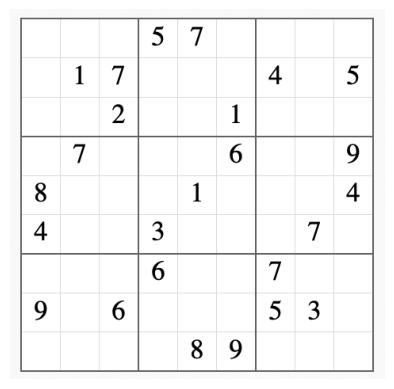

In [35]:

# Import the image and turn into grey scale
img = cv2.imread(IMAGE_PATH)
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(grey, cmap='gray')
plt.axis('off')
plt.show()

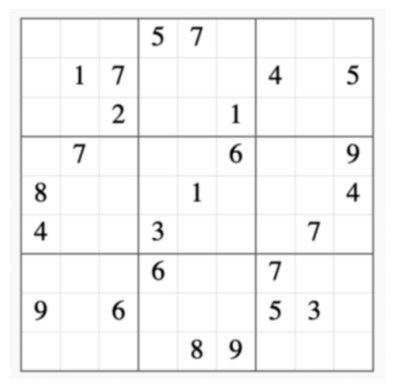

In [36]:
# Apply Gaussian blur effect to remove high frequency noises
blurred = cv2.GaussianBlur(grey, (5, 5), 0)

plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()

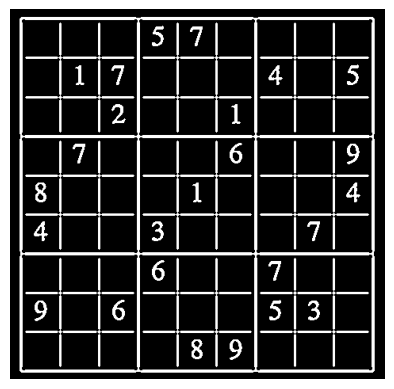

In [37]:
# Convert the blurry greyscale image into sharp black-and-white only image
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blockSize=11, C=2)

plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

In [38]:
# Find all the contours of the Sudoku board
# NOTE: the contours are unsorted
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort all of the contours in decending order
contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Extract the outer contour (which is the largest)
board_contour = contours[0]

# Calculate the perimeter
peri = cv2.arcLength(board_contour, True)

print(f"Perimeter: {peri}")

approx = cv2.approxPolyDP(board_contour, 0.01 * peri, True)

# Make sure that there are 4 vertices
if len(approx) != 4:
    raise ValueError("Could not find a 4-sided Sudoku board.")

Perimeter: 1791.9411249160767


In [39]:
def sort_corners(pts):
    # Helper to sort points: [top-left, top-right, bottom-right, bottom-left]
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

In [40]:
pts1 = np.float32([pts[0] for pts in approx])
sorted_pts = sort_corners(pts1)

print(f"Sorted corners:\n {sorted_pts}")

Sorted corners:
 [[ 14.  10.]
 [459.  12.]
 [457. 458.]
 [ 12. 456.]]


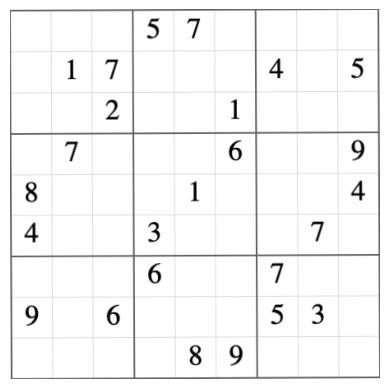

In [41]:
OUTPUT_SIZE = 450

dst_pts = np.array([
    [0, 0],                           # Top-Left destination
    [OUTPUT_SIZE - 1, 0],             # Top-Right destination
    [OUTPUT_SIZE - 1, OUTPUT_SIZE - 1], # Bottom-Right destination
    [0, OUTPUT_SIZE - 1]              # Bottom-Left destination
], dtype="float32")

# Calculate the perspective transform matrix
M = cv2.getPerspectiveTransform(sorted_pts, dst_pts)

# Wrap the original image to get the final flat square
flat_board = cv2.warpPerspective(grey, M, (OUTPUT_SIZE, OUTPUT_SIZE))

plt.imshow(flat_board, cmap='gray')
plt.axis('off')
plt.show()

In [42]:
# Answer
ans = [
  [0, 0, 0, 5, 7, 0, 0, 0, 0],
  [0, 1, 7, 0, 0, 0, 4, 0, 5],
  [0, 0, 2, 0, 0, 1, 0, 0, 0],
  [0, 7, 0, 0, 0, 6, 0, 0, 9],
  [8, 0, 0, 0, 1, 0, 0, 0, 4],
  [4, 0, 0, 3, 0, 0, 0, 7, 0],
  [0, 0, 0, 6, 0, 0, 7, 0, 0],
  [9, 0, 6, 0, 0, 0, 5, 3, 0],
  [0, 0, 0, 0, 8, 9, 0, 0, 0],
]

# Flatten the matrix
flattened_ans = [item for sublist in ans for item in sublist]

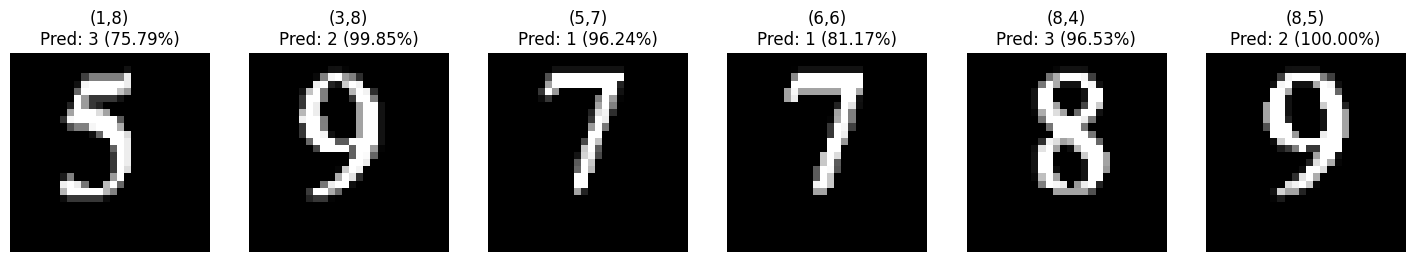

Accuracy: 92.59%


In [46]:
grid = []
cell_size = flat_board.shape[0] // 9
incorrect_cells = []

MODEL_PATH = ROOT_DIR / "models" / "digit_recognition_model_TMNIST.keras"

model = load_model(MODEL_PATH)

idx = 0
for r in range(9):
    row = []
    for c in range(9):
        # Crop the cell
        x1, y1 = c * cell_size, r * cell_size
        x2, y2 = x1 + cell_size, y1 + cell_size
        cell = flat_board[y1:y2, x1:x2]

        margin = int(cell_size * 0.1)
        cell = cell[margin:cell_size-margin, margin:cell_size-margin]

        #
        _, thresh_cell = cv2.threshold(cell, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # Calculate the number of white pixels
        total_pixels = thresh_cell.size
        white_pixels = np.sum(thresh_cell == 255)

        # Determine if the cell is empty based on the ration of the number of white pixels to the total pixels
        if (white_pixels / total_pixels) < 0.05:
            row.append(0)
        else:
            # Pipeline that process the input image
            cell_resized = cv2.resize(thresh_cell, (28, 28))
            cell_input = cell_resized.reshape(1, 28, 28, 1).astype("float32") / 255.0

            # Predict the digit
            predictions = model.predict(cell_input, verbose=0)
            predicted_digit = np.argmax(predictions, axis=-1)[0]
            confidence = np.max(predictions)

            if int(predicted_digit) != flattened_ans[idx]:
                # Save the meta data
                incorrect_cells.append({
                    'img': cell_resized.copy(),
                    'pos': (r, c),
                    'pred': predicted_digit,
                    'conf': confidence
                })

            row.append(int(predicted_digit))

        idx += 1

    grid.append(row)

if incorrect_cells:
    num_plots = len(incorrect_cells)
    fig, axes = plt.subplots(1, num_plots, figsize=(num_plots * 3, 3))

    # Handle the case where there is only 1 low confidence cell
    if num_plots == 1:
        axes = [axes]

    for ax, data in zip(axes, incorrect_cells):
        ax.imshow(data['img'], cmap='gray')
        ax.set_title(f"({data['pos'][0]},{data['pos'][1]})\nPred: {data['pred']} ({data['conf']:.2%})")
        ax.axis('off')
    plt.show()

print(f"Accuracy: {(1 - len(incorrect_cells) / 81) * 100:.2f}%")

# print("Grid: [")
# for row in grid:
#     print(f"  {row},")
# print("]")